<a href="https://colab.research.google.com/github/pranitgarje/Neural_Networks/blob/main/makemore_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
import random

In [5]:
words=open('names.txt','r').read().splitlines()

In [6]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [7]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}


In [8]:

random.seed(42)
random.shuffle(words)


In [9]:
len(words)

32033

In [10]:
words[:1]

['yuheng']

In [11]:
#building the dataset
block_size=3
X,Y=[],[]
for w in words[:1]:
  context=[0]*block_size
  for ch in w+'.':
    ix=stoi[ch]
    X.append(context)
    Y.append(ix)
    print(''.join(itos[i] for i in context), '--->', itos[ix])
    context=context[1:]+[ix]

X=torch.tensor(X)
Y=torch.tensor(Y)

... ---> y
..y ---> u
.yu ---> h
yuh ---> e
uhe ---> n
hen ---> g
eng ---> .


In [12]:
X.shape,X.dtype,Y.shape,Y.dtype

(torch.Size([7, 3]), torch.int64, torch.Size([7]), torch.int64)

In [13]:
C=torch.randn((27,2))

In [14]:
emb=C[X]
emb.shape


torch.Size([7, 3, 2])

In [15]:
W1=torch.randn((6,100))
b1=torch.randn(100)

In [16]:
h=torch.tanh(emb.view(-1,6)@ W1 + b1)

In [17]:
h.shape

torch.Size([7, 100])

In [18]:
W2=torch.randn((100,27))
b2=torch.randn((27))

In [19]:
logits=h @ W2 +b2

In [20]:
logits.shape

torch.Size([7, 27])

In [21]:
counts=logits.exp()

In [22]:
prob=counts/counts.sum(1,keepdims=True)

In [23]:
loss=-prob[torch.arange(7),Y].log().mean()

In [24]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [25]:

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [26]:
sum(p.nelement() for p in parameters)

11897

In [27]:
for p in parameters:
  p.requires_grad=True

In [28]:
lri=[]
lossi=[]
stepi=[]

In [29]:
for i in range(200000):
  ix=torch.randint(0,Xtr.shape[0],(32,))

  emb=C[Xtr[ix]]
  h=torch.tanh(emb.view(-1,30)@ W1 + b1)
  logits=h @ W2 +b2
  loss=F.cross_entropy(logits,Ytr[ix])

  for p in parameters:
    p.grad=None
  loss.backward()

  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  stepi.append(i)
  lossi.append(loss.log10().item())




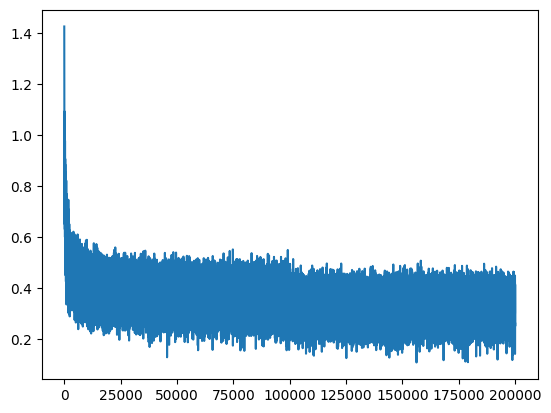

In [30]:
plt.plot(stepi, lossi)

In [31]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1287, grad_fn=<NllLossBackward0>)

In [32]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1680, grad_fn=<NllLossBackward0>)

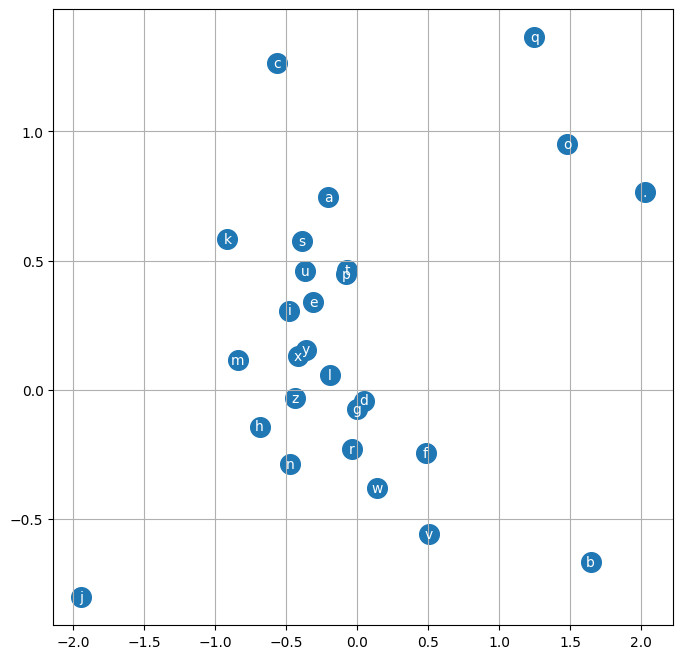

In [33]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [34]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [35]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

carlah.
amille.
khi.
mish.
taty.
salansherrahnee.
deliah.
jareei.
nelmari.
chaiivie.
legy.
dham.
jorn.
quint.
shon.
waina.
bick.
jero.
dearisi.
jace.
